In [216]:
import pandas as pd

df = pd.read_csv("accepted_2007_to_2018Q4.csv", nrows=50000)
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_13776\3458043121.py:3: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("accepted_2007_to_2018Q4.csv", nrows=50000)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [217]:
important_cols = [
    'loan_amnt','term','int_rate','installment',
    'grade','emp_length','home_ownership',
    'annual_inc','verification_status',
    'purpose','dti','delinq_2yrs',
    'revol_util','total_acc','loan_status'
]

df = df[important_cols]
df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,revol_util,total_acc,loan_status
0,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,29.7,13.0,Fully Paid
1,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,19.2,38.0,Fully Paid
2,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,56.2,18.0,Fully Paid
3,35000.0,60 months,14.85,829.90,C,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,11.6,17.0,Current
4,10400.0,60 months,22.45,289.91,F,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,64.5,35.0,Fully Paid


In [218]:
df['loan_status'].value_counts()

loan_status
Fully Paid            34978
Charged Off            9027
Current                5610
Late (31-120 days)      246
In Grace Period         100
Late (16-30 days)        38
Default                   1
Name: count, dtype: int64

In [219]:
df['loan_status'] = df['loan_status'].str.strip()

In [220]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

In [221]:
df['int_rate'] = df['int_rate'].astype(str).str.replace('%','').astype(float)
df['revol_util'] = df['revol_util'].astype(str).str.replace('%','').astype(float)

In [222]:
df['term'] = df['term'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_13776\3024662541.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['term'] = df['term'].str.extract('(\d+)').astype(int)


In [223]:
df['emp_length'] = df['emp_length'].str.extract('(\d+)')
df['emp_length'] = df['emp_length'].astype(float)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_13776\4003520313.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['emp_length'] = df['emp_length'].str.extract('(\d+)')


In [224]:
df['target'].value_counts(normalize=True)

target
0    0.794864
1    0.205136
Name: proportion, dtype: float64

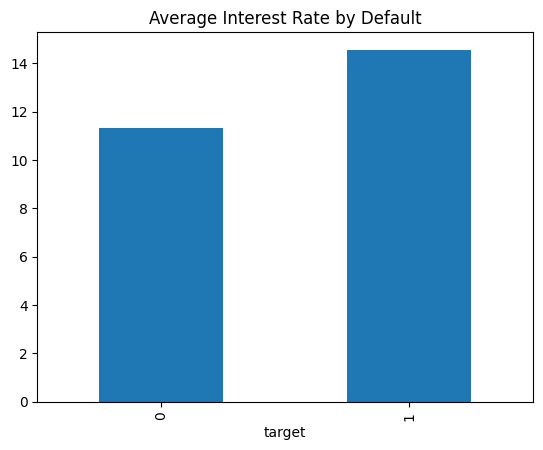

In [225]:
import matplotlib.pyplot as plt

df.groupby('target')['int_rate'].mean().plot(kind='bar')
plt.title('Average Interest Rate by Default')
plt.show()

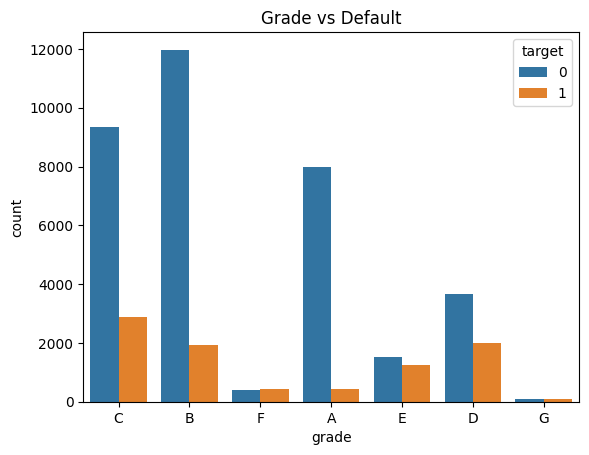

In [226]:
import seaborn as sns

sns.countplot(data=df, x='grade', hue='target')
plt.title('Grade vs Default')
plt.show()

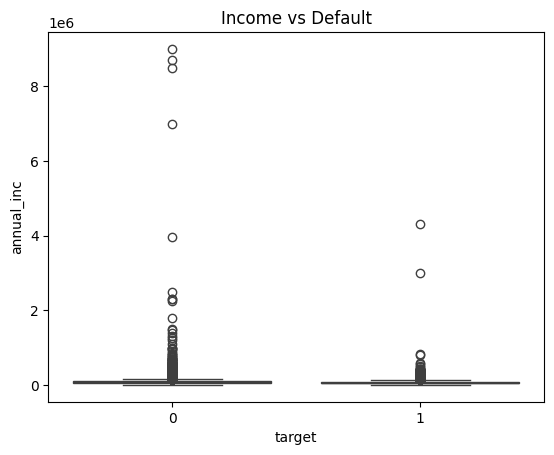

In [227]:
sns.boxplot(data=df, x='target', y='annual_inc')
plt.title('Income vs Default')
plt.show()

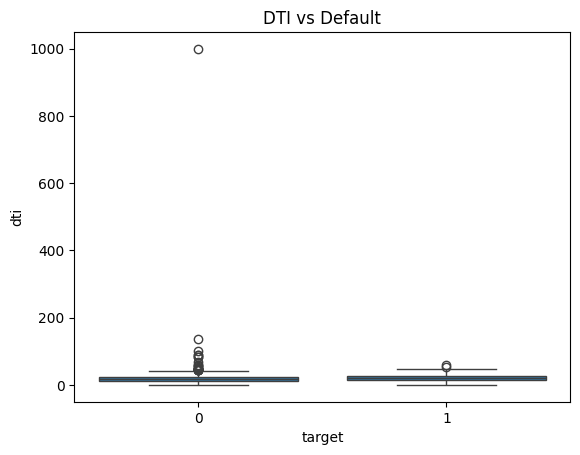

In [228]:
sns.boxplot(data=df, x='target', y='dti')
plt.title('DTI vs Default')
plt.show()

In [229]:
x = df.drop(columns=['loan_status','target'])
y = df['target']

In [230]:
x = pd.get_dummies(x,drop_first=True)
x = x.fillna(0)
x = x.astype(int)

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)


In [231]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [232]:
y_pred = model.predict(x_test)

In [233]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print('Accuracy:', accuracy_score(y_test,y_pred))

Accuracy: 0.784456311782752


In [234]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,y_pred))

[[6741  241]
 [1656  163]]
